<a href="https://colab.research.google.com/github/DebershiMitra/AI-Bootcamp/blob/main/Time_series_through_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

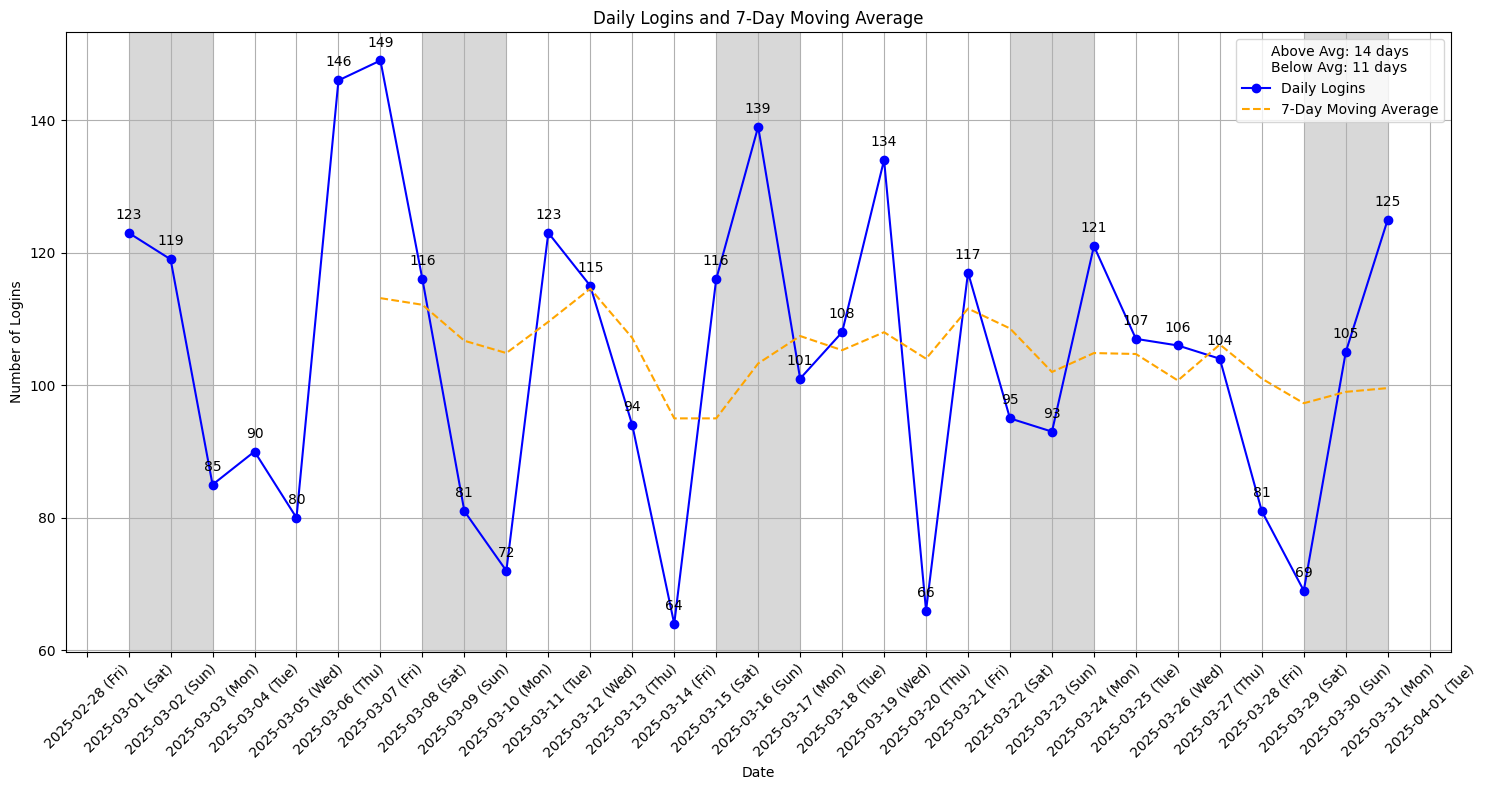

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Generate sample data for daily logins
import random
from datetime import timedelta

start_date = pd.to_datetime('2025-03-01')
end_date = pd.to_datetime('2025-03-31')
date_range = pd.date_range(start=start_date, end=end_date)

np.random.seed(42)  # For reproducibility
logins = [random.randint(50, 150) for _ in range(len(date_range))]

# Create a DataFrame
data = pd.DataFrame({'date': date_range, 'logins': logins})

# Convert the 'date' column to datetime format
data['date'] = pd.to_datetime(data['date'])

# Create a complete date range from the minimum to the maximum date in the data
date_range = pd.date_range(start=data['date'].min(), end=data['date'].max())

# Reindex the DataFrame to the full date range, filling missing dates with zero logins
data = data.set_index('date').reindex(date_range, fill_value=0).reset_index()
data.rename(columns={'index': 'date'}, inplace=True)

# Convert the 'logins' column back to integers if necessary
data['logins'] = data['logins'].astype(int)

# Calculate the 7-day moving average of the logins
data['7d_moving_avg'] = data['logins'].rolling(window=7).mean()

# Prepare for plotting
plt.figure(figsize=(15, 8))

# Plot daily logins using blue line chart with markers
plt.plot(data['date'], data['logins'], label='Daily Logins', color='blue', marker='o')

# Plot the 7-day moving average with an orange dashed line
plt.plot(data['date'], data['7d_moving_avg'], label='7-Day Moving Average', color='orange', linestyle='--')

# Highlight weekends with a specific background color
for i in range(len(data)):
    if data['date'][i].weekday() >= 5:  # Saturday and Sunday
        plt.axvspan(data['date'][i], data['date'][i] + pd.Timedelta(days=1), facecolor='grey', alpha=0.3)

# Annotate each data point with its corresponding login value, and adjust text y-position to above the line
for i, txt in enumerate(data['logins']):
    plt.annotate(txt, (data['date'][i], data['logins'][i]), textcoords="offset points", xytext=(0,10), ha='center')

# Custom legend indicating the number of days above and below the moving average
above_avg = np.sum(data['logins'] > data['7d_moving_avg'])
below_avg = np.sum(data['logins'] < data['7d_moving_avg'])
plt.legend(title=f"Above Avg: {above_avg} days\nBelow Avg: {below_avg} days")

# Format the x-axis to show the date with the day of the week
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d (%a)'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

# Add a title, axis labels, and a grid to the plot
plt.title('Daily Logins and 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Number of Logins')
plt.grid(True)

# Use a tight layout for the plot to ensure that labels and titles fit well within the display
plt.tight_layout()

# Display the plot
plt.show()

Here's the prompt:

1. Load the dataset into a pandas DataFrame.
2. Ensure that the 'date' column is converted to datetime format using pd.to_datetime().
3. Create a complete date range from the minimum to the maximum date in the data.
4. Reindex the DataFrame to the full date range, filling missing dates with zero logins and resetting the index.
5. Convert the 'logins' column back to integers if necessary.
6. Calculate the 7-day moving average of the logins.
7. Create a plot with the following specifications:
- Plot daily logins using blue line chart with markers .
- Plot the 7-day moving average with an orange dashed line.
- Highlight weekends with a specific background color.
- Annotate each data point with its corresponding login value, and adjust text y-position to above to line.
- Add a custom legend indicating the number of days above and below the moving average.
- Format the x-axis to show the date with the day of the week.
- Ensure the x-axis labels do not overlap and are easily readable.
8. Add a title, axis labels, and a grid to the plot.
9. Use a tight layout for the plot to ensure that labels and titles fit well within the display.
10. Display the plot.